In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.lorenz import LorenzIntraTrajectoryGLSConfig, run_lorenz_intra_trajectory_gls_experiment
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white", font_scale=1.1)

cfg = LorenzIntraTrajectoryGLSConfig(
    n_runs=25,
    t0=0.0,
    t1=10.0,
    dt=1e-3,
    noise_level=0.025,
    poly_degree=2,
    derivative_order=1,
    p=2,
    include_bias=False,
    stlsq_threshold=0.5,
    n_ensemble_models=100,
    seed_base=0,
    results_dir="results",
    results_filename="lorenz_weighted_errors.csv",
)


# Lorenz Part 2 — Intra-trajectory GLS

This notebook compares three different strategies for properly fit a SINDy model on a trajectory characterized by heteroskedastik noise: 
- *No weighting* (`WeakPDELibrary`)
- *Variance GLS* (`WeightedWeakPDELibrary`, weights = variance_scaled)
- *Unitary GLS* (`WeightedWeakPDELibrary`, weights = 1, only correlation effect)

## Governing equations

The classical Lorenz--63 system is given by

$$
\begin{aligned}
\dot{x} &= \sigma (y - x), \\
\dot{y} &= x(\rho - z) - y, \\
\dot{z} &= xy - \beta z.
\end{aligned}
$$

We use the standard parameter values $(\sigma, \rho, \beta) = (10, 28, 8/3)$.

Let $U=(x,y,z)^\top$ denote the system state. We model additive perturbation error by adding a zero-mean random noise term $\epsilon$ to $U$, that is,
$$
U^{\mathrm{noisy}} = U + \epsilon.
$$
Where
$$
\mathbb{E}[\epsilon] = 0,
\qquad
\mathrm{Var}(\epsilon) \propto \alpha^2 \|U\|^2.
$$

## Trajectories

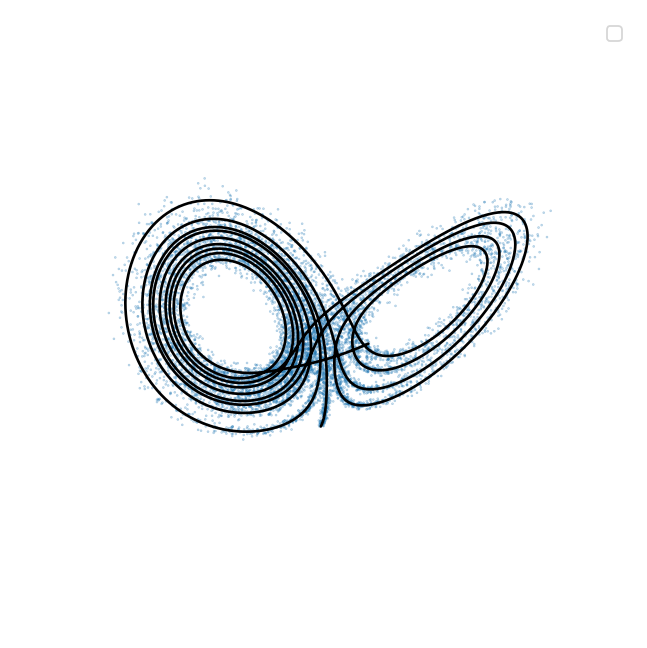

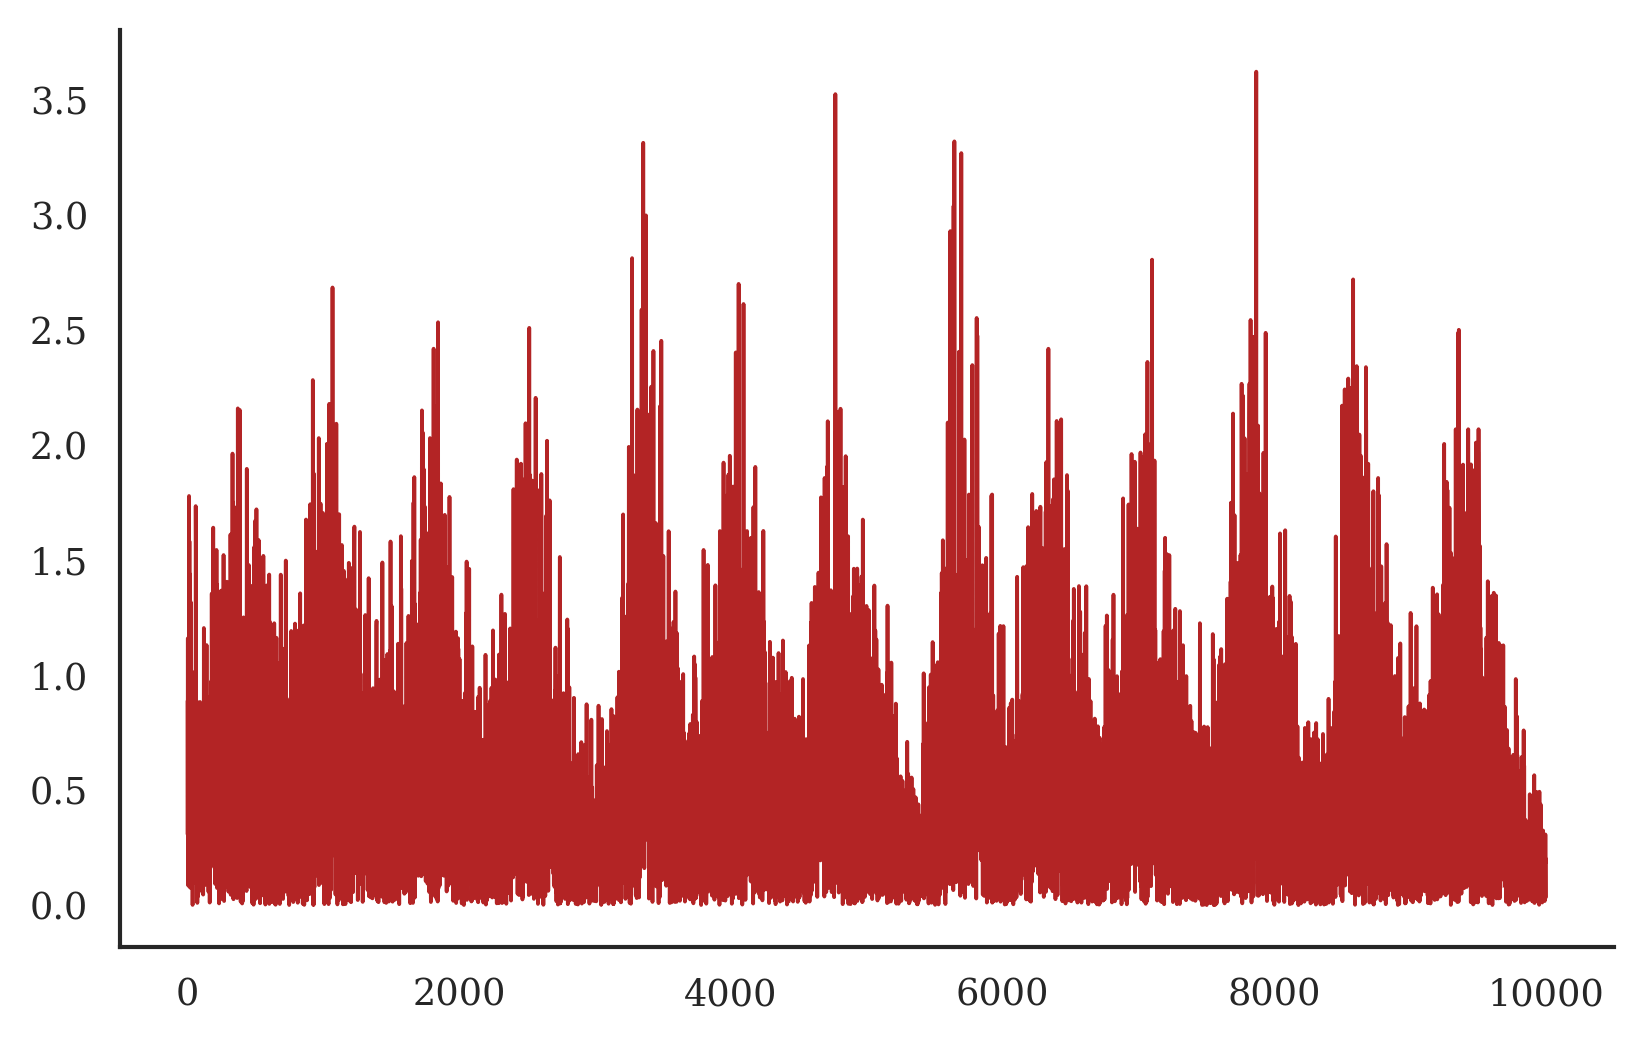

In [8]:
from mfsindy.cases.lorenz import generate_lorenz_trajectory
from mfsindy.cases.lorenz_plots import plot_trajectories_additive_noise, plot_residuals

y0 = np.array([10.0,-10.0,30.0])
_, X_true, _ = generate_lorenz_trajectory(
    y0=y0,
    noise_level=0.0,
    seed=0,
    T=10
)
X_noisy = plot_trajectories_additive_noise(x_true=X_true,alpha=0.025)
plot_residuals(x_true=X_true, x_noisy=X_noisy)


## Run

In [3]:
df_errors, L1_errors, L0_errors = run_lorenz_intra_trajectory_gls_experiment(cfg)


Monte Carlo Lorenz GLS: 100%|██████████| 25/25 [04:14<00:00, 10.20s/it]


In [7]:
# ---------------------------------------------------------------------
# Reload CSV and reconstruct error dicts for plotting
# ---------------------------------------------------------------------

errors_path = os.path.join(cfg.results_dir, cfg.results_filename)
df_errors = pd.read_csv(errors_path)

methods = ["No weighting", "Variance GLS", "Ones GLS"]

L1_errors = {
    m: df_errors[
        (df_errors["method"] == m) & (df_errors["metric"] == "L1")
    ]["value"].to_numpy()
    for m in methods
}
L0_errors = {
    m: df_errors[
        (df_errors["method"] == m) & (df_errors["metric"] == "L0")
    ]["value"].to_numpy()
    for m in methods
}

print("\nL1 errors (first few, reloaded from CSV):")
for m in methods:
    print(m, np.median(L1_errors[m]))

print("\nL0 support errors (first few, reloaded from CSV):")
for m in methods:
    print(m, np.median(L0_errors[m]))



L1 errors (first few, reloaded from CSV):
No weighting 0.1130274120224458
Variance GLS 0.0087681778615952
Ones GLS 0.0098238792032009

L0 support errors (first few, reloaded from CSV):
No weighting 0.1428571428571428
Variance GLS 0.0
Ones GLS 0.0


## Error Plots

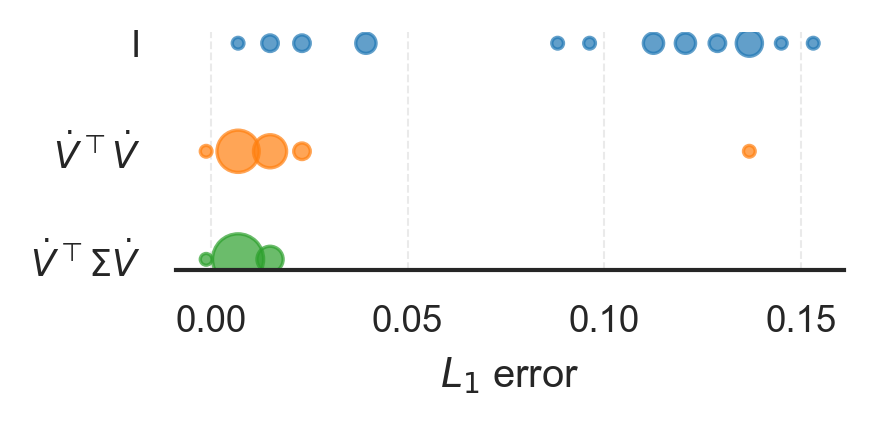

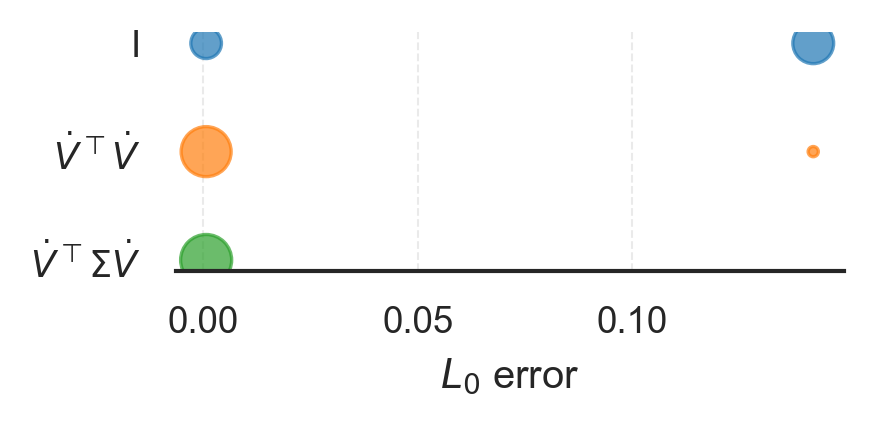

In [6]:
# ---------------------------------------------------------------------
# Bubble-hist plots for L1 and L0
# ---------------------------------------------------------------------
method_colors = {
    "No weighting": "tab:blue",
    "Variance GLS": "tab:green",
    "Ones GLS": "tab:orange",
}
methods = ["Variance GLS", "Ones GLS", "No weighting"]
labels = [r"$\dot{V}^\top\Sigma\dot{V}$",r"$\dot{V}^\top\dot{V}$","I"]

bubble_hist(
    errors_dict=L1_errors,
    xlabel=r"$L_1$ error",
    n_bins=20,
    models_order=methods,
    colors=method_colors,
    labels=labels
)

bubble_hist(
    errors_dict=L0_errors,
    xlabel=r"$L_0$ error",
    n_bins=10,
    models_order=methods,
    colors=method_colors,
    labels=labels
)
